In [3]:
from careamics.careamist import CAREamist
from careamics.config.factories import create_n2v_config

# create a configuration
config = create_n2v_config(
    experiment_name="n2v_training",
    data_type="array",  
    axes="YX",
    patch_size=[64, 64],
    batch_size=8,
    num_epochs=30,
)

# instantiate a careamist
careamist = CAREamist(config)


No working directory provided. Using current working directory: /var/home/maartenpaul/Documents/GitHub/NL-BioImageAnalysis-course2026.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [2]:
from tifffile import imread, imwrite

image = imread("/var/home/maartenpaul/Downloads/example.tif")



In [4]:

# train the model
careamist.train(train_data=image)  

# once trained, predict


Seed set to 819914538
Seed set to 819914538
Computing mean/std statistics: 100%|██████████| 358/358 [00:00<00:00, 5080.77it/s]
Computed mean-std for input: means = [9.563752], stds = [2.05303157]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ UNet             │  333 K │ train │     0 │
│ 1 │ metrics │ MetricCollection │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 333 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 333 K                                                                                                
Total estimated model params size (MB): 1.335                                                                      
Modules in train mode: 41                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/var/home/maartenpaul/miniforge3/envs/2026_denoising/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/var/home/maartenpaul/miniforge3/envs/2026_denoising/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (44) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


In [6]:
predictions, sources = careamist.predict(pred_data=image)


Creating prediction output directory: '/var/home/maartenpaul/Documents/GitHub/NL-BioImageAnalysis-course2026'
Restoring states from the checkpoint path at /var/home/maartenpaul/Documents/GitHub/NL-BioImageAnalysis-course2026/checkpoints/n2v_training_0/n2v_training_last.ckpt
Loaded model weights from the checkpoint at /var/home/maartenpaul/Documents/GitHub/NL-BioImageAnalysis-course2026/checkpoints/n2v_training_0/n2v_training_last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

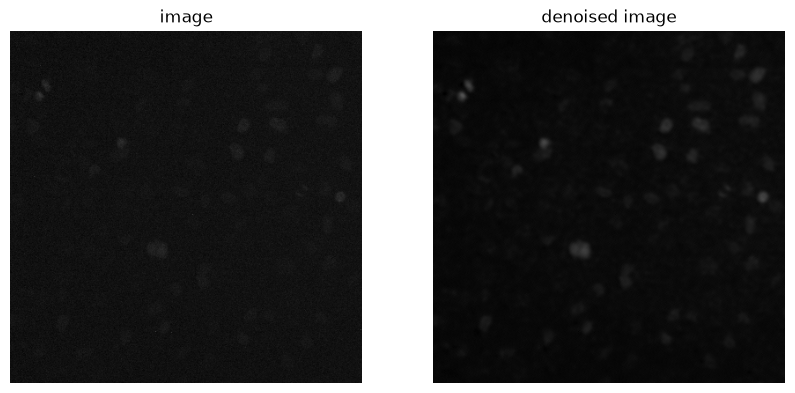

In [21]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# The raw image
_ = axs[0].imshow(image[200:600,200:600], cmap="gray",vmax=100)
_ = axs[0].set_title("image")
# The same image with the labels on top
_ = axs[1].imshow(predictions[0][200:600,200:600], cmap="gray", vmax=50)
_ = axs[1].set_title("denoised image")
for ax in axs:
    _ = ax.axis("off")

In [9]:
image.max()

np.uint16(982)